In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/dataset"

train_path = DATASET_PATH + "/train"
val_path = DATASET_PATH + "/val"
test_path = DATASET_PATH + "/test"

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
train_data = datasets.ImageFolder(train_path, transform=train_transforms)
val_data = datasets.ImageFolder(val_path, transform=val_transforms)
test_data = datasets.ImageFolder(test_path, transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

class_names = train_data.classes
print("Classes:", class_names)

Classes: ['Brown Planthopper', 'Rice Gall Midge', 'Rice Hispa', 'Rice Leaf Folder', 'Rice Stem Borer']


In [ ]:
model = models.resnet50(pretrained=True)

# Freeze layers (SE optimization)
for param in model.parameters():
    param.requires_grad = False

# Custom classifier
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, len(class_names))
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 91.0MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.0001)

In [ ]:
def train_model(model, epochs=15):
    best_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        val_acc = evaluate(model, val_loader)

        print(f"Epoch {epoch+1} | Loss: {train_loss:.3f} | Val Acc: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")

    return model

In [ ]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100 * correct / total

In [ ]:
model = train_model(model, epochs=15)

Epoch 1 | Loss: 45.523 | Val Acc: 61.76%
Epoch 2 | Loss: 38.580 | Val Acc: 59.31%
Epoch 3 | Loss: 32.372 | Val Acc: 61.76%
Epoch 4 | Loss: 29.053 | Val Acc: 61.76%
Epoch 5 | Loss: 25.725 | Val Acc: 61.76%
Epoch 6 | Loss: 23.473 | Val Acc: 61.27%
Epoch 7 | Loss: 21.934 | Val Acc: 62.75%
Epoch 8 | Loss: 20.332 | Val Acc: 60.29%
Epoch 9 | Loss: 19.012 | Val Acc: 63.73%
Epoch 10 | Loss: 17.614 | Val Acc: 63.73%
Epoch 11 | Loss: 17.794 | Val Acc: 65.20%
Epoch 12 | Loss: 15.822 | Val Acc: 63.73%
Epoch 13 | Loss: 15.532 | Val Acc: 63.73%
Epoch 14 | Loss: 15.574 | Val Acc: 65.69%
Epoch 15 | Loss: 14.779 | Val Acc: 66.18%


In [ ]:
model.load_state_dict(torch.load("best_model.pth"))

test_acc = evaluate(model, test_loader)
print("Test Accuracy:", test_acc)

Test Accuracy: 85.09615384615384


In [ ]:
def predict_image(image_path, threshold=0.6):
    model.eval()

    img = Image.open(image_path).convert("RGB")
    img = val_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        probs = F.softmax(output, dim=1)

        confidence, pred = torch.max(probs, 1)

    confidence = confidence.item()
    pred_class = class_names[pred.item()]

    if confidence < threshold:
        return "Unknown Pest (OOD)", confidence
    else:
        return pred_class, confidence

Saving Screenshot 2026-04-30 230220.png to Screenshot 2026-04-30 230220.png


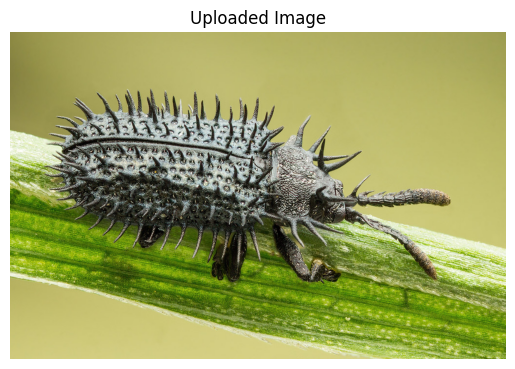

Prediction: Rice Hispa
Confidence: 0.982154130935669


In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get uploaded file name
image_path = list(uploaded.keys())[0]

# Show image
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

# Predict
result, conf = predict_image(image_path)

print("Prediction:", result)
print("Confidence:", conf)

In [ ]:
torch.save(model.state_dict(), "pest_model.pth")

In [ ]:
from google.colab import files
files.download("pest_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=15, scale=(0.9,1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

train_data = datasets.ImageFolder(train_path, transform=train_transforms)
val_data = datasets.ImageFolder(val_path, transform=val_transforms)
test_data = datasets.ImageFolder(test_path, transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

class_names = train_data.classes

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet50(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# 🔥 UNFREEZE LAST BLOCK
for param in model.layer4.parameters():
    param.requires_grad = True

# Custom head
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, len(class_names))
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5   # 🔥 important
)

In [ ]:
best_acc = 0

for epoch in range(25):   # 🔥 more epochs
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1} | Loss: {train_loss:.3f} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

Epoch 1 | Loss: 48.048 | Val Acc: 36.76%
Epoch 2 | Loss: 44.606 | Val Acc: 48.04%
Epoch 3 | Loss: 40.566 | Val Acc: 56.86%
Epoch 4 | Loss: 35.131 | Val Acc: 61.27%
Epoch 5 | Loss: 29.667 | Val Acc: 65.69%
Epoch 6 | Loss: 24.463 | Val Acc: 66.67%
Epoch 7 | Loss: 19.243 | Val Acc: 71.57%
Epoch 8 | Loss: 15.732 | Val Acc: 74.02%
Epoch 9 | Loss: 13.409 | Val Acc: 74.51%
Epoch 10 | Loss: 11.141 | Val Acc: 75.00%
Epoch 11 | Loss: 9.777 | Val Acc: 76.47%
Epoch 12 | Loss: 8.483 | Val Acc: 76.96%
Epoch 13 | Loss: 7.600 | Val Acc: 78.92%
Epoch 14 | Loss: 6.695 | Val Acc: 79.90%
Epoch 15 | Loss: 6.125 | Val Acc: 80.39%
Epoch 16 | Loss: 5.860 | Val Acc: 80.39%
Epoch 17 | Loss: 4.975 | Val Acc: 80.88%
Epoch 18 | Loss: 4.564 | Val Acc: 80.88%
Epoch 19 | Loss: 4.060 | Val Acc: 80.88%
Epoch 20 | Loss: 4.144 | Val Acc: 80.39%
Epoch 21 | Loss: 3.595 | Val Acc: 81.37%
Epoch 22 | Loss: 2.929 | Val Acc: 81.37%
Epoch 23 | Loss: 2.820 | Val Acc: 81.86%
Epoch 24 | Loss: 3.284 | Val Acc: 81.37%
Epoch 25 | Loss

In [ ]:
torch.save(model.state_dict(), "best_model.pth")

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))

model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * correct / total
print("Test Accuracy:", test_acc)

Test Accuracy: 93.26923076923077


                   precision    recall  f1-score   support

Brown Planthopper       1.00      0.88      0.94        42
  Rice Gall Midge       0.93      0.95      0.94        42
       Rice Hispa       0.93      0.95      0.94        42
 Rice Leaf Folder       0.83      0.93      0.87        41
  Rice Stem Borer       1.00      0.95      0.97        41

         accuracy                           0.93       208
        macro avg       0.94      0.93      0.93       208
     weighted avg       0.94      0.93      0.93       208



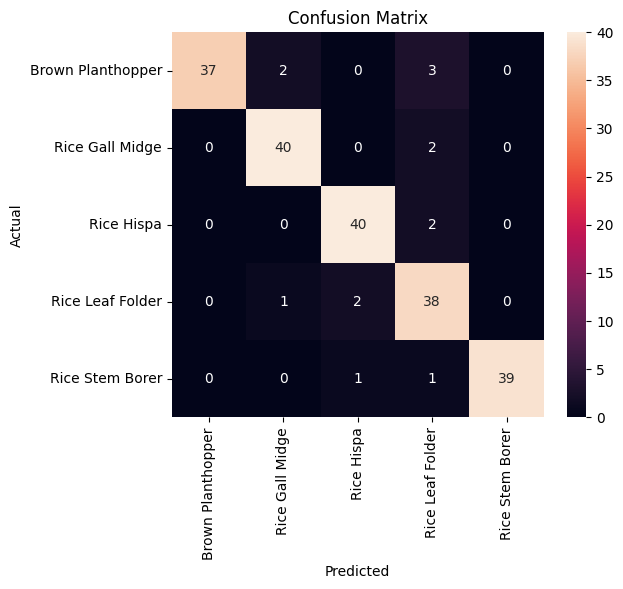

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import torch.nn.functional as F
from PIL import Image

def predict_image(image_path, threshold=0.7):  # 🔥 stricter
    model.eval()

    img = Image.open(image_path).convert("RGB")
    img = val_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        probs = F.softmax(output, dim=1)

        confidence, pred = torch.max(probs, 1)

    confidence = confidence.item()
    pred_class = class_names[pred.item()]

    if confidence < threshold:
        return "Unknown Pest (OOD)", confidence
    else:
        return pred_class, confidence

In [ ]:
from google.colab import files
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

result, conf = predict_image(img_path)

print(f"Prediction: {result}")
print(f"Confidence: {conf*100:.2f}%")

KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), "final_pest_model.pth")

In [ ]:
# Load best model first
model.load_state_dict(torch.load("best_model.pth"))

# Unfreeze layer3 + layer4 🔥
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

In [ ]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5   # 🔥 small LR for fine-tuning
)

In [ ]:
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [ ]:
best_acc = 0

for epoch in range(20):   # fine-tune epochs
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = 100 * correct / total

    print(f"[FineTune] Epoch {epoch+1} | Loss: {train_loss:.3f} | Val Acc: {val_acc:.2f}%")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model_finetuned.pth")
        print(f"🔥 Fine-tuned model saved! Acc: {best_acc:.2f}%")

    scheduler.step()

[FineTune] Epoch 1 | Loss: 2.530 | Val Acc: 82.84%
🔥 Fine-tuned model saved! Acc: 82.84%
[FineTune] Epoch 2 | Loss: 2.052 | Val Acc: 82.35%
[FineTune] Epoch 3 | Loss: 2.125 | Val Acc: 82.35%
[FineTune] Epoch 4 | Loss: 1.445 | Val Acc: 82.35%
[FineTune] Epoch 5 | Loss: 1.861 | Val Acc: 82.84%
[FineTune] Epoch 6 | Loss: 1.217 | Val Acc: 81.86%
[FineTune] Epoch 7 | Loss: 1.347 | Val Acc: 82.84%
[FineTune] Epoch 8 | Loss: 0.706 | Val Acc: 82.35%
[FineTune] Epoch 9 | Loss: 1.137 | Val Acc: 82.84%
[FineTune] Epoch 10 | Loss: 0.860 | Val Acc: 82.84%
[FineTune] Epoch 11 | Loss: 0.860 | Val Acc: 82.35%
[FineTune] Epoch 12 | Loss: 0.651 | Val Acc: 82.35%
[FineTune] Epoch 13 | Loss: 0.706 | Val Acc: 81.86%
[FineTune] Epoch 14 | Loss: 0.696 | Val Acc: 82.35%
[FineTune] Epoch 15 | Loss: 1.178 | Val Acc: 82.35%
[FineTune] Epoch 16 | Loss: 0.792 | Val Acc: 82.84%
[FineTune] Epoch 17 | Loss: 1.018 | Val Acc: 82.35%
[FineTune] Epoch 18 | Loss: 0.746 | Val Acc: 82.84%
[FineTune] Epoch 19 | Loss: 0.847 |

In [ ]:
model.load_state_dict(torch.load("best_model_finetuned.pth"))

test_acc = evaluate(model, test_loader)
print("🔥 Final Test Accuracy:", test_acc)

🔥 Final Test Accuracy: 92.78846153846153


In [ ]:
from google.colab import files
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

result, conf = predict_image(img_path)

print(f"Prediction: {result}")
print(f"Confidence: {conf*100:.2f}%")

Saving Untitled.jpeg to Untitled (3).jpeg
Prediction: Brown Planthopper
Confidence: 87.41%
